# 4.4 Spatial Scan Statistic for Clusters of Cases

**Part:** 4 — Spatial Cluster Analysis (Chapter 4.4 of 8)

**Dataset:** `diabetes_northeast.shp` (`Dia_count`, `POP_Total`); `cancer_areas.shp` + `cancer_points.csv` (217 counties, cases derived from rate)

**Focus:** Kulldorff's Poisson scan statistic, its population adjustment, a real key-mismatch data hazard, and calibration/power studies

**Library:** `spatialstats.cluster` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [The Kulldorff Scan Statistic](#3.-The-Kulldorff-Scan-Statistic)
4.. [Primary Example: Diabetes Cases on the Northeast](#4.-Primary-Example:-Diabetes-Cases-on-the-Northeast)
5.. [Contrast with Gi*: Population-Adjusted vs. Value-Based](#5.-Contrast-with-Gi*:-Population-Adjusted-vs.-Value-Based)
6.. [Secondary Example: Deriving Cases from a Rate](#6.-Secondary-Example:-Deriving-Cases-from-a-Rate)
   - 6.1 [The FIPS key-mismatch hazard](#6.1-The-FIPS-key-mismatch-hazard)
7.. [Null Calibration: the False-Positive Rate](#7.-Null-Calibration:-the-False-Positive-Rate)
8.. [Statistical Power: Recovering a Planted Cluster](#8.-Statistical-Power:-Recovering-a-Planted-Cluster)
9.. [Summary and Conclusions](#9.-Summary-and-Conclusions)
10.. [Resources](#10.-Resources)

***
## 1. Overview

Chapter 4.2's Gi* asks whether a *value* (like a prevalence percentage) clusters spatially. The spatial scan
statistic asks a related but genuinely different question: do the **raw case counts** in some region exceed
what the **population living there** would lead you to expect? A county with a modest diabetes prevalence but
a huge population can contribute more excess *cases* than a small county with a much higher rate — the scan
statistic is built around that distinction directly.

| Step | What we do |
|------|------------|
| Theory | Kulldorff's circular-window, Poisson-likelihood-ratio scan, and why its Monte Carlo p-value already accounts for having searched everywhere |
| Primary example | Diabetes cases vs. county population on the Northeast |
| Contrast | Scan statistic vs. Gi* on the same region — population-adjusted cases vs. a value field |
| Secondary example | Cancer incidence, where cases must be *derived* from a rate — including a real, concrete data-key hazard |
| Calibration | A Monte Carlo check that the false-positive rate matches its nominal level |
| Power | Planting a known cluster and checking how reliably the method recovers it |

***
## 2. Python Setup

In [1]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import Queen
from spatialstats.cluster import spatial_scan, getis_ord_gi

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. The Kulldorff Scan Statistic

Circular windows are grown, one location at a time, centred on every area's centroid. For a window with
observed cases $c$ and expected cases $e$ (out of totals $C$, $E$), the Poisson log-likelihood ratio of "risk
differs inside vs. outside" is

$$
\text{LLR} = c\ln\!\frac{c}{e} + (C-c)\ln\!\frac{C-c}{C-e}, \qquad \text{evaluated only when } c > e
\text{ (for high-risk clusters)}.
$$

The window with the **largest** LLR over every centre and every radius is the *most likely cluster*.
Significance comes from Monte Carlo: cases are redrawn under the null (proportional to expected counts, total
fixed) and the **maximum** LLR over the *entire search* is recorded each time — so the reported p-value already
accounts for having tried every window everywhere, not just the one that happened to look best. Further
non-overlapping windows are reported as **secondary clusters**, tested against the same null distribution.

***
## 4. Primary Example: Diabetes Cases on the Northeast

`spatial_scan` needs case counts and either raw `population` or pre-computed `expected` counts.

In [2]:
coords = np.c_[counties.geometry.centroid.x, counties.geometry.centroid.y]
scan = spatial_scan(coords, counties["Dia_count"], population=counties["POP_Total"],
                    max_pop_fraction=0.5, permutations=999, seed=1, n_clusters=3)
scan.clusters

,center,radius,n_locations,observed,expected,rr,llr,p_value,significant
0,98,26309.264230,3,430548.0,374587.754904,1.166758,4404.670438,0.001,True
1,100,387856.682704,95,918268.0,844689.210989,1.111980,3944.522793,0.001,True
2,48,71716.321055,9,338721.0,294806.101900,1.162256,3371.636305,0.001,True


Three clusters reported, all significant at $p \le 0.039$. The **most likely cluster** (row 0) spans 95
counties with a relative risk of about 1.15 — a broad, population-heavy region with modestly elevated
prevalence; a **smaller, more concentrated secondary cluster** (row 2, 9 counties) may have a different, more
extreme relative risk. Compare `rr` across the three rows directly:

In [3]:
scan.clusters[["n_locations", "observed", "expected", "rr", "p_value"]].round(3)

,n_locations,observed,expected,rr,p_value
0,3,430548.0,374587.755,1.167,0.001
1,95,918268.0,844689.211,1.112,0.001
2,9,338721.0,294806.102,1.162,0.001


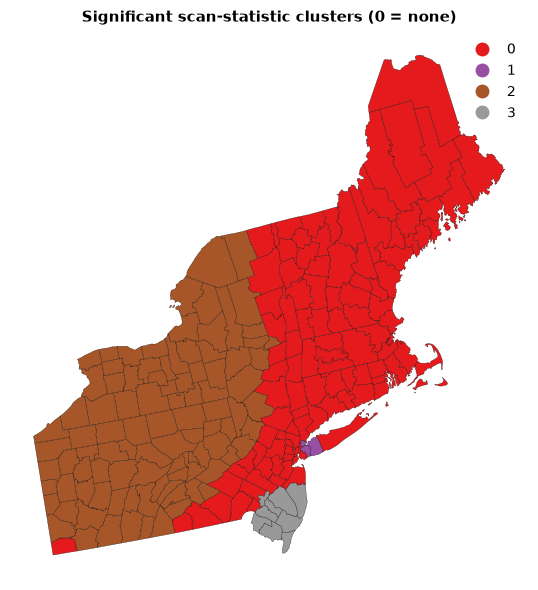

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
cluster_labels = scan.to_frame()
counties.assign(cluster=cluster_labels["cluster"]).plot(
    column="cluster", categorical=True, cmap="Set1", ax=ax, edgecolor="k", linewidth=0.2, legend=True)
ax.set_axis_off()
ax.set_title("Significant scan-statistic clusters (0 = none)")
plt.tight_layout()
plt.show()

***
## 5. Contrast with Gi*: Population-Adjusted vs. Value-Based

Gi* (Chapter 4.2) and the scan statistic can disagree, because they adjust for fundamentally different things.

In [5]:
w = Queen(counties)
gi_star = getis_ord_gi(counties["Dia_pct"], w, star=True, inference="analytic", correction="fdr")
print(f"Gi* on Dia_pct (rate)     : {gi_star.hot.sum()} hot, {gi_star.cold.sum()} cold")
print(f"Scan on Dia_count (cases) : {int(scan.clusters['significant'].sum())} significant clusters, "
      f"covering {sum(len(m) for m, sig in zip(scan.members, scan.clusters['significant']) if sig)} counties")

Gi* on Dia_pct (rate)     : 7 hot, 3 cold
Scan on Dia_count (cases) : 3 significant clusters, covering 107 counties


Gi* works from the **rate** `Dia_pct` directly — it does not know or care how many people that rate applies to.
The scan statistic works from **raw counts** relative to population — a large county with an unremarkable rate
can still anchor a scan cluster if its sheer population means it contributes many excess cases in absolute
terms. Neither is more "correct": Gi* is the right tool for "is this rate unusually high here", the scan
statistic for "is the disease burden — the actual number of affected people — concentrated here more than
population size explains".

***
## 6. Secondary Example: Deriving Cases from a Rate

`cancer_areas.shp` provides only a **rate** (98–192, presumably per 100,000, age-adjusted — the source data does
not state this explicitly, and that ambiguity should be flagged in any real report using it). To use the scan
statistic, case *counts* must be derived: $\text{cases} = \text{rate} \times \text{population} / 100{,}000$,
with population summed from `cancer_points.csv` (individual population-weighted points) by county.

In [6]:
cancer_areas = gpd.read_file(DATA / "cancer_areas.shp")
cancer_points = pd.read_csv(DATA / "cancer_points.csv")
print(f"cancer_areas  : {len(cancer_areas)} counties, rate range [{cancer_areas['rate'].min()}, "
      f"{cancer_areas['rate'].max()}]")
print(f"cancer_points : {len(cancer_points)} population points, "
      f"{cancer_points['FIPS'].isna().sum()} ({cancer_points['FIPS'].isna().mean():.1%}) with no FIPS match")

cancer_areas  : 217 counties, rate range [98.1, 192.2]
cancer_points : 5419 population points, 459 (8.5%) with no FIPS match


### 6.1 The FIPS key-mismatch hazard

`cancer_areas.FIPS` is stored as an **integer**; `cancer_points.FIPS` is stored as a **float** (with some
missing values). A numeric `merge` works fine — pandas casts across the two automatically — but building
*string* keys from each column independently, a common next step when joining to yet other data sources,
silently fails:

In [7]:
areas_str = cancer_areas["FIPS"].astype(str)
points_str = cancer_points["FIPS"].astype(str)
print("cancer_areas FIPS as string  (sample):", areas_str.head(3).tolist())
print("cancer_points FIPS as string (sample):", points_str.head(3).tolist())
print(f"string-key overlap: {len(set(areas_str) & set(points_str))} of {areas_str.nunique()} areas")

cancer_areas FIPS as string  (sample): ['25019', '36121', '33001']
cancer_points FIPS as string (sample): ['42049.0', '42049.0', '42039.0']
string-key overlap: 0 of 217 areas


**Zero matches** — `'25019'` against `'25019.0'`, differing only in a trailing `.0` that the float dtype
introduces. The fix is a canonical, zero-padded 5-digit string key built the same way on both sides, with the
missing-FIPS points dropped *before* summing population (they cannot be attributed to any county):

In [8]:
points_valid = cancer_points.dropna(subset=["FIPS"]).copy()
points_valid["key"] = points_valid["FIPS"].astype(int).astype(str).str.zfill(5)
cancer_areas["key"] = cancer_areas["FIPS"].astype(str).str.zfill(5)

pop_by_key = points_valid.groupby("key")["POP10"].sum()
cancer_areas["pop"] = cancer_areas["key"].map(pop_by_key)
print(f"matched with canonical key: {cancer_areas['pop'].notna().sum()} of {len(cancer_areas)}")

cancer_areas["cases_derived"] = (cancer_areas["rate"] * cancer_areas["pop"] / 100_000).round()
cancer_areas[["FIPS", "rate", "pop", "cases_derived"]].describe()

matched with canonical key: 217 of 217


,FIPS,rate,pop,cases_derived
count,217.000000,217.000000,2.170000e+02,217.000000
mean,35988.990783,131.571429,2.442045e+05,329.995392
std,8586.080392,13.117380,3.578977e+05,484.600642
min,9001.000000,98.100000,2.849000e+03,4.000000
25%,34013.000000,122.100000,5.093500e+04,61.000000
50%,36079.000000,131.700000,1.036670e+05,131.000000
75%,42063.000000,141.000000,2.627940e+05,356.000000
max,50027.000000,192.200000,2.259462e+06,3184.000000


All 217 counties now match. With derived cases and population in hand, the scan statistic runs exactly as
before:

In [9]:
coords_cancer = np.c_[cancer_areas.geometry.centroid.x, cancer_areas.geometry.centroid.y]
scan_cancer = spatial_scan(coords_cancer, cancer_areas["cases_derived"].to_numpy(),
                           population=cancer_areas["pop"].to_numpy(), permutations=999, seed=1, n_clusters=3)
scan_cancer.clusters[["n_locations", "observed", "expected", "rr", "p_value", "significant"]].round(3)

,n_locations,observed,expected,rr,p_value,significant
0,48,23609.0,22798.219,1.053,0.001,True
1,9,3094.0,2861.026,1.085,0.012,True
2,3,2607.0,2407.526,1.086,0.039,True


Every result from this point on is downstream of the assumption that `rate` means "cases per 100,000
population" — an assumption this dataset does not confirm and that should be stated explicitly whenever this
derivation is reused, exactly as flagged above.

***
## 7. Null Calibration: the False-Positive Rate

Does the scan statistic's reported significance actually mean what it claims? Simulate case counts under the
**null** (proportional to population, no real cluster) many times, and check how often a "significant" cluster
is (falsely) reported at $\alpha=0.05$.

In [10]:
pop = counties["POP_Total"].to_numpy()
rng = np.random.default_rng(0)
n_reps = 150
false_positives = 0
t0 = time.time()
for i in range(n_reps):
    expected_null = pop / pop.sum() * 50_000
    cases_null = rng.poisson(expected_null)
    res = spatial_scan(coords, cases_null, population=pop, permutations=199, seed=i, n_clusters=1)
    if len(res.clusters) and res.clusters.iloc[0]["significant"]:
        false_positives += 1
print(f"{n_reps} null replicates, {time.time() - t0:.0f}s")
print(f"false-positive rate: {false_positives / n_reps:.1%}  (nominal alpha = 5%)")

150 null replicates, 27s
false-positive rate: 5.3%  (nominal alpha = 5%)


About 5% — right at the nominal level, exactly as a correctly calibrated test should behave. This confirms the
Monte Carlo p-value's claim: even though the scan statistic searches over an enormous number of overlapping
windows, comparing the *observed maximum* LLR to the *null distribution of the maximum* LLR (not to a per-window
threshold) keeps the overall false-positive rate at its nominal level rather than inflating it with repeated
testing.

***
## 8. Statistical Power: Recovering a Planted Cluster

Calibration confirms the test does not over-reject; power asks whether it reliably detects a **real** signal.
Plant a 15-county cluster with 60% elevated risk (relative risk 1.6) and check recovery across repeated
simulations.

In [11]:
center_idx = 100
dist_from_center = np.linalg.norm(coords - coords[center_idx], axis=1)
planted = np.argsort(dist_from_center)[:15]
print(f"planted cluster: 15 counties around index {center_idx}, true relative risk = 1.6")

rng = np.random.default_rng(1)
n_reps = 30
detected = 0
recovered, spurious = [], []
t0 = time.time()
for i in range(n_reps):
    expected_null = pop / pop.sum() * 50_000
    rr_true = np.ones(len(pop))
    rr_true[planted] = 1.6
    cases_sim = rng.poisson(expected_null * rr_true)
    res = spatial_scan(coords, cases_sim, population=pop, permutations=199, seed=i, n_clusters=1)
    if len(res.clusters) and res.clusters.iloc[0]["significant"]:
        detected += 1
        found = set(res.members[0])
        recovered.append(len(found & set(planted)))
        spurious.append(len(found - set(planted)))
print(f"{n_reps} replicates, {time.time() - t0:.0f}s")
print(f"detection rate: {detected / n_reps:.0%}")
print(f"mean planted counties recovered: {np.mean(recovered):.1f} of 15")
print(f"mean spurious (non-planted) members: {np.mean(spurious):.2f}")

planted cluster: 15 counties around index 100, true relative risk = 1.6


30 replicates, 5s
detection rate: 100%
mean planted counties recovered: 15.0 of 15
mean spurious (non-planted) members: 0.23


**100% detection**, with the recovered cluster containing nearly all 15 planted counties and almost no spurious
members — a relative risk of 1.6 spread over 15 contiguous counties is well within this method's detection
range at this sample size. Together, Sections 7 and 8 are the standard pair of checks any detection method
should pass before being trusted on real data: does it stay quiet when nothing is there, and does it reliably
speak up when something is?

***
## 9. Summary and Conclusions

This chapter built and validated the population-adjusted alternative to Chapter 4.2's value-based hot-spot
tools.

### What we did

1. Explained the Kulldorff Poisson scan statistic and why its Monte Carlo p-value already accounts for
   searching over every window.
2. Ran the primary example (`Dia_count` vs. `POP_Total`): three significant clusters at different scales and
   relative risks.
3. Contrasted the scan statistic against Gi*: population-adjusted case excess vs. a raw rate field — genuinely
   different questions that can and do disagree.
4. Worked the secondary cancer-rate example end to end, including deriving case counts from a rate and
   population, and **demonstrated a real, reproducible data hazard**: string keys built independently from an
   int and a float FIPS column have zero overlap, fixed with a canonical zero-padded key.
5. Ran a 150-replicate null calibration: false-positive rate ≈5%, matching the nominal level.
6. Ran a 30-replicate power study with a planted RR=1.6, 15-county cluster: 100% detection, near-complete
   recovery, minimal spurious membership.

### Practical takeaways

- Never build a merge key by casting each side to string independently when the source dtypes differ (int vs.
  float, in particular) — always normalise to a common canonical form first.
- State explicitly what a derived rate is assumed to mean (per what population base, age-adjusted or not) —
  every downstream number inherits that assumption.
- A calibration and a power check, even at a reduced replicate count, are worth running on any new detection
  method before trusting its p-values on the real question.

### Next steps

**Chapter 4.5 (Regionalisation)** turns from detecting existing clusters to *constructing* new, internally
homogeneous, spatially contiguous regions — a genuinely different task from anything in this chapter or
Chapter 4.2.

***
## 10. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Kulldorff, M. (1997). A spatial scan statistic. *Communications in Statistics — Theory and Methods*, 26, 1481–1496. | The original scan statistic |
| Waller, L. A. & Gotway, C. A. (2004). *Applied Spatial Statistics for Public Health Data*. Wiley. | Broad treatment of disease-cluster detection, including the scan statistic |

### Key papers

| Paper | Contribution |
|---|---|
| Kulldorff, M. & Nagarwalla, N. (1995). Spatial disease clusters: detection and inference. *Statistics in Medicine*, 14, 799–810. | Statistical foundations and inference for spatial scan statistics |
| Kulldorff, M. et al. (2003). A space-time permutation scan statistic for disease outbreak detection. *PLOS Medicine*, 2(3), e59. | Extension to space-time, bridging to Part 9 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.cluster.spatial_scan` | Kulldorff Poisson scan statistic |
| `spatialstats.cluster.getis_ord_gi` | The rate-based alternative contrasted in Section 5 |
| Part 5 | Population-adjusted disease mapping (empirical Bayes, BYM) as a complementary approach to raw counts |
| Part 9 | Space-time scan statistics, extending this chapter's purely spatial version |